# Trabajo Práctico Integrador: Análisis de Desempeño y Gestión de Estudiantes 🎓
**Materia:** Análisis de Datos Inicial  
**Carrera:** Tecnicatura Universitaria en Programación (TUP)

**Integrantes del grupo:**
1. Cristian Krahulik
2. Tomas Mastropietro
3. Juan Segura
4. Lautaro Castillo

---

## Hito 1: Elección y Planteo 🎯

**Dataset elegido:** `Student Performance and Behaviour.csv` (Trabajando sobre `dataset_DIRTY.csv` para la fase de limpieza).

**Descripción del Dataset:**
Este conjunto de datos contiene registros detallados de estudiantes universitarios, integrando variables académicas, demográficas y socioeconómicas. Cuenta con información sobre:
*   **Factores Académicos:** GPA previo, horas de estudio semanales, tasa de asistencia, materias falladas y notas de exámenes (parcial y final).
*   **Factores de Estilo de Vida:** Horas de sueño, niveles de estrés, uso de redes sociales y participación en actividades extracurriculares.
*   **Entorno y Contexto:** Calidad de conexión a internet, calidad del espacio de estudio, nivel educativo de los padres y nivel de ingresos familiar.
*   **Factores Psicológicos:** Puntuaciones de motivación y autoeficacia.

**Objetivos del Análisis (Preguntas a responder):**
1.  **Sobre el Riesgo Académico:** ¿En qué medida el agotamiento físico y mental —representado por altos niveles de estrés y pocas horas de sueño— anula el beneficio del esfuerzo académico, prediciendo un bajo rendimiento en el examen final independientemente de cuánto tiempo dedique el alumno a estudiar?
2.  **Sobre la Brecha Digital:** ¿Cómo condiciona la calidad de la conexión a internet la efectividad de las horas de estudio semanales? ¿Existe un punto crítico en la conectividad por debajo del cual el esfuerzo del estudiante deja de verse reflejado en sus calificaciones?
3.  **Sobre Comportamientos Atípicos:** ¿Qué hábitos diferencian a los estudiantes con éxito por estudio autónomo (aquellos con baja asistencia pero notas sobresalientes) de los estudiantes con ansiedad ante los exámenes (que dedican muchísimas horas al estudio pero obtienen resultados muy bajos)?

In [27]:
# Importación de librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import json

# Añadimos el directorio raíz al path para poder importar desde 'src'
sys.path.append(os.path.abspath(os.path.join('..')))

# Configuración visual básica para los gráficos
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

---
## Hito 2: ETL y Calidad de Datos 🧹

En esta fase realizamos un proceso avanzado de **Auditoría -> Limpieza -> Normalización -> Feature Engineering**.
Utilizamos un módulo externo `src/etl.py` para asegurar la consistencia del motor de datos.

In [28]:
from src.etl import auditar_datos

# 1. Carga del dataset con ruido
path_sucio = os.path.join('..', 'data', 'dataset_DIRTY.csv')
df_crudo = pd.read_csv(path_sucio)

# 2. Auditoría Inicial
reporte_inicial = auditar_datos(df_crudo)
print("=== REPORTE DE AUDITORÍA (DATASET SUCIO) ===")
print(json.dumps(reporte_inicial, indent=4, ensure_ascii=False))

print("\nVisualización rápida de inconsistencias (GPA negativo o Edades imposibles):")
cols_interes = ['Student_ID', 'Age', 'Previous_GPA', 'Weekly_Study_Hours']
display(df_crudo[(df_crudo['Previous_GPA'] < 0) | (df_crudo['Age'] > 100)].head(5)[cols_interes])

=== REPORTE DE AUDITORÍA (DATASET SUCIO) ===
{
    "total_filas": 500100,
    "duplicados": 100,
    "columnas_con_nulos": {
        "Previous_GPA": 10001,
        "Weekly_Study_Hours": 5002,
        "Attendance_Rate": 5001
    },
    "outliers": {
        "edad_invalida": 100,
        "gpa_invalido": 50,
        "horas_estudio_imposibles": 30
    },
    "valores_negativos_genericos": {
        "Previous_GPA": 50
    }
}

Visualización rápida de inconsistencias (GPA negativo o Edades imposibles):


,Student_ID,Age,Previous_GPA,Weekly_Study_Hours
1197,234739,150,2.58,2.0
13042,428636,150,2.40,19.2
18663,176891,26,-5.00,16.9
31246,456966,22,-5.00,20.8
33479,174766,150,3.58,23.7


### Aplicación de Limpieza e Ingeniería de Variables
Ejecutamos el motor de ETL que normaliza strings y crea nuevas variables diagnósticas.

In [29]:
from src.etl import limpiar_datos, crear_caracteristicas

# 3. Ejecución de la Limpieza y Normalización
df_clean = limpiar_datos(df_crudo)

# 4. Feature Engineering (Creación de nuevas variables)
df_final = crear_caracteristicas(df_clean)

# 5. Verificación Final
reporte_final = auditar_datos(df_final)
print("=== REPORTE DE AUDITORÍA (DATASET FINAL) ===")
print(json.dumps(reporte_final, indent=4, ensure_ascii=False))

print("\nNuevas variables creadas para el análisis:")
display(df_final[['Eficiencia_Estudio', 'Indice_Desgaste', 'Alerta_Riesgo']].head())

# Guardamos el resultado final
path_clean = os.path.join('..', 'data', 'dataset_CLEAN.csv')
df_final.to_csv(path_clean, index=False)
print(f"\n✅ Dataset limpio y enriquecido guardado en: {path_clean}")

=== REPORTE DE AUDITORÍA (DATASET FINAL) ===
{
    "total_filas": 500000,
    "duplicados": 0,
    "columnas_con_nulos": {},
    "outliers": {
        "edad_invalida": 0,
        "gpa_invalido": 0,
        "horas_estudio_imposibles": 0
    },
    "valores_negativos_genericos": {}
}

Nuevas variables creadas para el análisis:


,Eficiencia_Estudio,Indice_Desgaste,Alerta_Riesgo
0,3.368098,0.900000,False
1,3.925466,0.557143,False
2,3.021978,1.197368,False
3,3.380645,0.478873,True
4,2.871212,0.686275,False



✅ Dataset limpio y enriquecido guardado en: ..\data\dataset_CLEAN.csv


---
## Hito 3: Análisis y Visualización 📊

Es momento de explorar los datos visualmente y responder a las preguntas planteadas en el Hito 1 utilizando el dataset limpio `df_final`.

In [30]:
# Estadística Descriptiva General
df_final.describe()

,Student_ID,Semester_ID,Age,Family_Size,Internet_Quality,Study_Space_Quality,Previous_GPA,Number_of_Failed_Courses,Total_Credits_Earned,Weekly_Study_Hours,Attendance_Rate,Library_Visits_Per_Month,Extracurricular_Hours,Sleep_Hours,Social_Media_Usage_Hours,Stress_Level,Motivation_Score,Self_Efficacy_Score,Midterm_Mark,Final_Exam_Score,Eficiencia_Estudio,Indice_Desgaste
count,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000
mean,250000.500000,4.500100,23.490720,5.002176,6.565998,6.453566,2.788636,1.334232,67.501920,18.157505,79.626512,9.224000,3.984422,6.800725,2.948750,5.520213,5.987168,4.539254,53.763787,57.570266,4.191359,0.826571
std,144337.711635,2.292028,4.025972,2.001290,2.187664,2.077266,0.667427,1.487346,35.840162,7.872297,13.131068,3.712289,3.972895,1.199408,2.778273,1.970166,1.947749,1.486886,10.395511,11.309997,3.597159,0.340007
min,1.000000,1.000000,17.000000,2.000000,1.000000,1.000000,0.000000,0.000000,12.000000,2.000000,0.000000,0.000000,0.000000,3.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.090090
25%,125000.750000,2.000000,20.000000,3.000000,5.100000,5.000000,2.340000,0.000000,36.000000,12.700000,72.700000,7.000000,1.100000,6.000000,0.900000,4.200000,4.600000,3.520000,46.800000,50.400000,2.551282,0.591549
50%,250000.500000,5.000000,23.000000,5.000000,6.700000,6.500000,2.800000,1.000000,68.000000,18.100000,81.900000,9.000000,2.800000,6.800000,2.100000,5.500000,6.000000,4.540000,53.600000,57.600000,3.181319,0.800000
75%,375000.250000,6.000000,27.000000,7.000000,8.200000,8.000000,3.260000,2.000000,96.000000,23.400000,89.200000,12.000000,5.500000,7.600000,4.200000,6.900000,7.400000,5.550000,60.500000,64.800000,4.271692,1.031250
max,500000.000000,8.000000,30.000000,8.000000,10.000000,10.000000,4.000000,10.000000,144.000000,40.000000,100.000000,24.000000,30.000000,11.000000,12.000000,10.000000,10.000000,10.000000,100.000000,100.000000,47.619048,3.225806


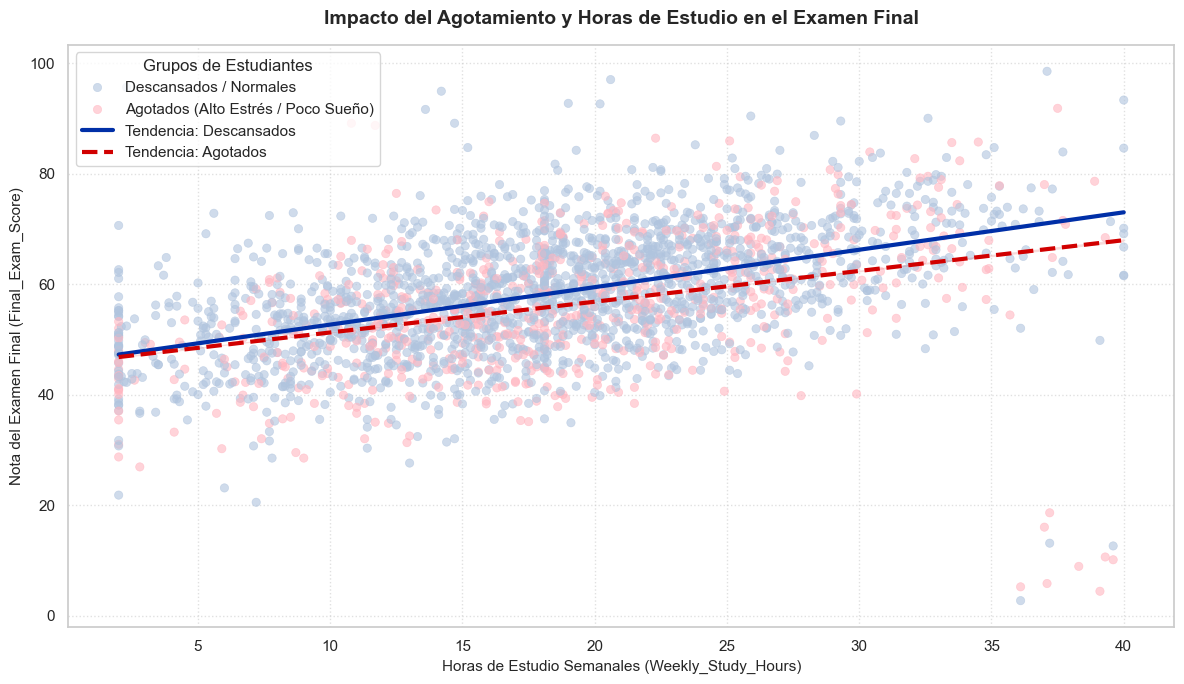

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carga de datos
df = pd.read_csv(os.path.join('..', 'data', 'dataset_CLEAN.csv'))

# Definir los promedios y crear los grupos
# Calculamos los promedios usando los 50.000 datos para máxima precisión
promedio_estres = df['Stress_Level'].mean()
promedio_sueno = df['Sleep_Hours'].mean()

# Condición de agotamiento (estrés alto Y sueño bajo)
condicion_agotado = (df['Stress_Level'] > promedio_estres) & (df['Sleep_Hours'] < promedio_sueno)

# Creamos la nueva columna. Por defecto todos son 'Descansados/Normales'
df['Estado_Agotamiento'] = 'Descansados / Normales'
# A los que cumplen la condición, los etiquetamos como 'Agotados (Alto Estrés / Poco Sueño)'
df.loc[condicion_agotado, 'Estado_Agotamiento'] = 'Agotados (Alto Estrés / Poco Sueño)'

# Muestra aleatoria para el gráfico
df_muestra = df.sample(n=2500, random_state=42)

# Construcción del gráfico
# Seteamos el tamaño de la ventana del gráfico
plt.figure(figsize=(12, 7))

# 1. Dibujo  los puntos (Scatter Plot) usando la muestra de 2000 datos
sns.scatterplot(
    data=df_muestra, 
    x='Weekly_Study_Hours', 
    y='Final_Exam_Score', 
    hue='Estado_Agotamiento',
    palette={'Descansados / Normales': '#B0C4DE', 'Agotados (Alto Estrés / Poco Sueño)': '#FFB6C1'}, # Gris azulado y Rosa suave
    alpha=0.6,
    edgecolor=None
)

# 2. Dibujo las líneas de tendencia usando los 50.000 datos completos
# Esto asegura que la línea represente la realidad absoluta del dataset
sns.regplot(
    data=df[df['Estado_Agotamiento'] == 'Descansados / Normales'],
    x='Weekly_Study_Hours',
    y='Final_Exam_Score',
    scatter=False, 
    label='Tendencia: Descansados',
    color='#002FA7', 
    line_kws={'linewidth': 3, 'linestyle': '-'} 
)

sns.regplot(
    data=df[df['Estado_Agotamiento'] == 'Agotados (Alto Estrés / Poco Sueño)'],
    x='Weekly_Study_Hours',
    y='Final_Exam_Score',
    scatter=False,
    label='Tendencia: Agotados',
    color='#D10000', 
    line_kws={'linewidth': 3, 'linestyle': '--'} 
)

# Estética
plt.title('Impacto del Agotamiento y Horas de Estudio en el Examen Final', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Horas de Estudio Semanales (Weekly_Study_Hours)', fontsize=11)
plt.ylabel('Nota del Examen Final (Final_Exam_Score)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title='Grupos de Estudiantes', loc='upper left')

plt.tight_layout()
plt.show()

# Pregunta 1: El Impacto del Agotamiento en el Rendimiento Académico

# Análisis Visual y Métricas Clave
* **Efecto limitante del desgaste:** El análisis demuestra que el agotamiento físico y mental —definido por altos niveles de estrés y pocas horas de sueño— no anula por completo el beneficio del esfuerzo, pero sí lo reduce y limita de forma significativa.
* **Retorno de la inversión de tiempo:** Dedicar más horas al estudio semanal (`Weekly_Study_Hours`) se traduce en una mejora del rendimiento final (`Final_Exam_Score`) para ambos grupos. Sin embargo, la tasa de retorno de ese esfuerzo (la pendiente de la línea) es notablemente menor para los alumnos que sufren de agotamiento.
* **Ampliación de la brecha:** A medida que aumentan las horas de estudio, la diferencia de rendimiento entre un alumno descansado y uno agotado se amplía. Al llegar a las 40 horas semanales, un estudiante en un entorno saludable obtiene, en promedio, **5 puntos más** en su examen final que un compañero con alta carga de estrés y falta de sueño que dedicó exactamente el mismo tiempo.

---

**Conclusión sobre el Riesgo Académico:**

El análisis de los datos demuestra que el agotamiento físico y mental (definido por altos niveles de estrés y pocas horas de sueño) **no anula por completo** el beneficio del esfuerzo académico, pero **sí lo reduce y lo limita de forma significativa**.

Como se observa en el gráfico de dispersión, dedicar más horas al estudio semanal (`Weekly_Study_Hours`) se traduce en una mejora del rendimiento final (`Final_Exam_Score`) para ambos grupos de estudiantes. Sin embargo, la tasa de retorno de ese esfuerzo es notablemente menor para los alumnos que sufren de agotamiento. 

A medida que aumentan las horas de estudio, la brecha de rendimiento entre un alumno descansado y uno agotado se amplía. Al llegar a las 40 horas de estudio semanales, un estudiante en un entorno saludable (bajo estrés y buen descanso) obtiene, en promedio, **5 puntos más** en su examen final que un compañero con alta carga de estrés y falta de sueño que dedicó exactamente el mismo tiempo de estudio.

**En conclusión:** El esfuerzo mitiga parte del impacto negativo del agotamiento, pero el bienestar físico y mental actúa como un amplificador indispensable para alcanzar el máximo potencial académico. Estudiar bajo un estado de desgaste severo genera un rendimiento decreciente.

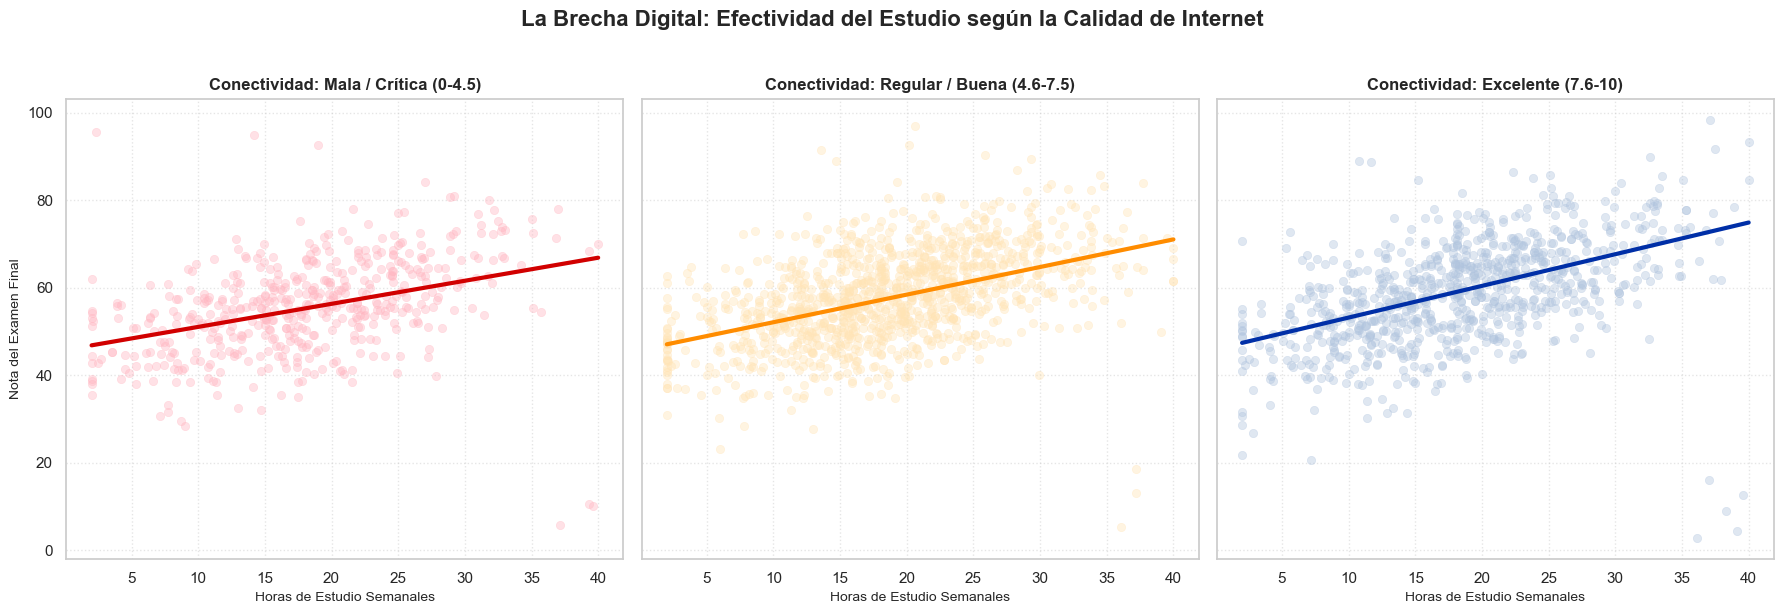

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv(os.path.join('..', 'data', 'dataset_CLEAN.csv'))

# Creo los 3 rangos ajustados (Binning)
cortes = [0, 4.5, 7.5, 10]
nombres_rangos = ['Mala / Crítica (0-4.5)', 'Regular / Buena (4.6-7.5)', 'Excelente (7.6-10)']

# Clasifico a los alumnos
df['Rango_Internet'] = pd.cut(df['Internet_Quality'], bins=cortes, labels=nombres_rangos, include_lowest=True)

# Muestra aleatoria
df_muestra = df.sample(n=2500, random_state=42)

# Graficos
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

colores_puntos = ['#FFB6C1', '#FFE4B5', '#B0C4DE'] # Rosa, Naranja suave, Azul suave
colores_lineas = ['#D10000', '#FF8C00', '#002FA7'] # Rojo, Naranja intenso, Azul Francia

for i, rango in enumerate(nombres_rangos):
    
    datos_completos_rango = df[df['Rango_Internet'] == rango]
    datos_muestra_rango = df_muestra[df_muestra['Rango_Internet'] == rango]
    
    # Puntos de fondo
    sns.scatterplot(
        data=datos_muestra_rango,
        x='Weekly_Study_Hours',
        y='Final_Exam_Score',
        color=colores_puntos[i],
        alpha=0.4,
        edgecolor=None,
        ax=axes[i]
    )
    
    # Línea de tendencia 
    sns.regplot(
        data=datos_completos_rango,
        x='Weekly_Study_Hours',
        y='Final_Exam_Score',
        scatter=False,
        color=colores_lineas[i],
        line_kws={'linewidth': 3},
        ax=axes[i]
    )
    
    # Estética
    axes[i].set_title(f'Conectividad: {rango}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Horas de Estudio Semanales', fontsize=10)
    if i == 0:
        axes[i].set_ylabel('Nota del Examen Final', fontsize=10)
    axes[i].grid(True, linestyle=':', alpha=0.5)

# Título
plt.suptitle('La Brecha Digital: Efectividad del Estudio según la Calidad de Internet', fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()


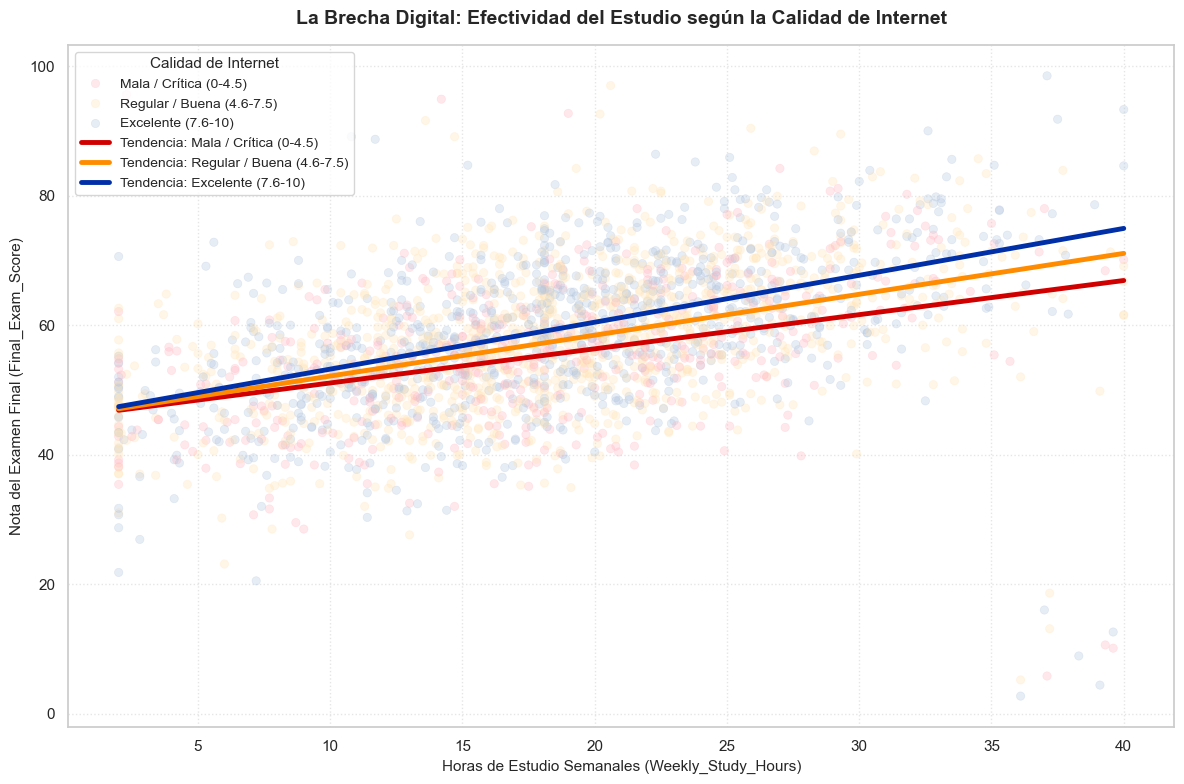

Rango_Internet
Mala / Crítica (0-4.5)       55.361740
Regular / Buena (4.6-7.5)    57.280427
Excelente (7.6-10)           59.120692
Name: Final_Exam_Score, dtype: float64


In [33]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv(os.path.join('..', 'data', 'dataset_CLEAN.csv'))

cortes = [0, 4.5, 7.5, 10]
nombres_rangos = ['Mala / Crítica (0-4.5)', 'Regular / Buena (4.6-7.5)', 'Excelente (7.6-10)']
df['Rango_Internet'] = pd.cut(df['Internet_Quality'], bins=cortes, labels=nombres_rangos, include_lowest=True)

df_muestra = df.sample(n=2500, random_state=42)

plt.figure(figsize=(12, 8))

colores_puntos = {
    'Mala / Crítica (0-4.5)': '#FFB6C1',       
    'Regular / Buena (4.6-7.5)': '#FFE4B5',     
    'Excelente (7.6-10)': '#B0C4DE'            
}

colores_lineas = {
    'Mala / Crítica (0-4.5)': '#D10000',       
    'Regular / Buena (4.6-7.5)': '#FF8C00',    
    'Excelente (7.6-10)': '#002FA7'            
}



sns.scatterplot(
    data=df_muestra,
    x='Weekly_Study_Hours',
    y='Final_Exam_Score',
    hue='Rango_Internet',
    palette=colores_puntos,
    alpha=0.3,          
    edgecolor=None
)

for rango in nombres_rangos:
    sns.regplot(
        data=df[df['Rango_Internet'] == rango],
        x='Weekly_Study_Hours',
        y='Final_Exam_Score',
        scatter=False,                      
        color=colores_lineas[rango],
        label=f'Tendencia: {rango}',
        line_kws={'linewidth': 3.5}         
    )


plt.title('La Brecha Digital: Efectividad del Estudio según la Calidad de Internet', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Horas de Estudio Semanales (Weekly_Study_Hours)', fontsize=11)
plt.ylabel('Nota del Examen Final (Final_Exam_Score)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.5)

plt.legend(title='Calidad de Internet', loc='upper left', fontsize=10, title_fontsize=11)

plt.tight_layout()
plt.show()
# Esto nos agrupa por rango de internet y nos calcula el promedio de la nota final
print(df.groupby('Rango_Internet')['Final_Exam_Score'].mean())

### Pregunta 2: El Impacto de la Brecha Digital en el Rendimiento Académico

#### Análisis Visual y Métricas Clave
* **Punto de partida equitativo:** En niveles bajos de estudio (entre 2 y 5 horas semanales), la calidad de la conexión a internet no genera una diferencia significativa; todos los estudiantes promedian un rendimiento similar (~47 puntos).
* **Efecto de divergencia progresiva:** A medida que se incrementan las horas de estudio, las líneas de tendencia se abren en "abanico". La pendiente es notablemente más pronunciada en el grupo con conectividad **Excelente (7.6-10)**, intermedia en **Regular / Buena (4.6-7.5)**, y más plana en **Mala / Crítica (0-4.5)**.
* **La brecha en el esfuerzo máximo:** Un alumno con internet excelente que dedica 40 horas semanales alcanza una nota tendencial cercana a los **75 puntos**. En contraposición, un alumno con conectividad mala que realiza el mismo sacrificio (40 horas) se estanca en los **67 puntos**, consolidando una **brecha digital de 8 puntos** en el rendimiento máximo.

---

**Conclusión sobre la Brecha Digital:**

La calidad de la conexión a internet **condiciona de forma directa y progresiva la efectividad de las horas de estudio**. A mejor conectividad, el estudiante experimenta un mayor "retorno" por su esfuerzo; es decir, cada hora invertida se traduce en un incremento más alto en la nota final, lo que se evidencia en la mayor pendiente de la línea de tendencia del grupo con internet Excelente (7.6-10).

Respecto a la existencia de un **punto crítico**, los datos demuestran que **no existe un umbral por debajo del cual el esfuerzo se anule por completo**. Incluso en el rango de conectividad "Mala / Crítica (0-4.5)", la línea mantiene una trayectoria firmemente ascendente, lo que significa que el estudio sigue dando frutos independientemente de las limitaciones tecnológicas.

Sin embargo, la baja conectividad genera una **penalización por ineficiencia**. El internet deficiente actúa como un techo invisible para el rendimiento: a medida que aumentan las horas de estudio semanales, las líneas se distancian cada vez más. Al alcanzar las 40 horas de estudio, un alumno con internet deficiente obtiene, en promedio, **8 puntos menos** que un compañero con internet excelente que le dedicó el mismo tiempo. 

**En conclusión:** El mal internet no detiene el deseo de superación del alumno, pero lo obliga a esforzarse significativamente más para alcanzar los mismos resultados.

---
## Hito 4: Interfaz Gráfica (Dashboard) 🖥️

El diferencial técnico del proyecto. Se debe presentar un dashboard interactivo utilizando Streamlit que permita al usuario filtrar los datos en tiempo real.

### 🛠️ Especificaciones Técnicas
1.  **Interactividad:** Widgets para filtrar por comisiones, carreras o niveles de riesgo.
2.  **KPIs:** Métricas de aprobación y promedios generales actualizables.
3.  **Visualización:** Gráficos dinámicos basados en los filtros seleccionados.

*Nota: La aplicación se encuentra en el archivo `app.py` o dentro de la carpeta `src/`. Para ejecutarla use `streamlit run app.py`.*

---
## Hito 5: Informe de Gestión y Propuestas 🚀

Basados en la evidencia recolectada, completen el diagnóstico final:

### 1. Diagnóstico Académico
*¿Qué historias cuentan los datos?*

### 2. Propuestas de Mejora (Justificadas)
* **Propuesta A:** [Acción]
* **Propuesta B:** [Acción]

### 3. Conclusión Final
*Impacto esperado de las propuestas.*